# Lab 2 — Digital Image Fundamentals
**ARTI 403 – Image Processing**

**Outcome #1:** Explain how digital images are represented and manipulated in a computer.

---
## 1. Image Sampling and Quantization

### Step 1: Import the libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Define Functions

In [2]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()

### Step 3: Import the image and set the parameters

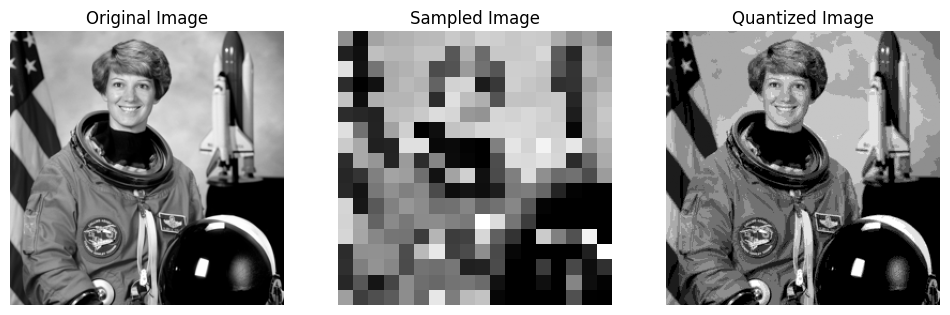

In [3]:
image_path='../images/lena_gray_256.tif'
sampling_factor=14
quantization_levels=9
# Load image in grayscale (np.fromfile handles Arabic/Unicode paths on Windows)
original_image = cv2.imdecode(np.fromfile(image_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

---
## 2. Arithmetic Operations

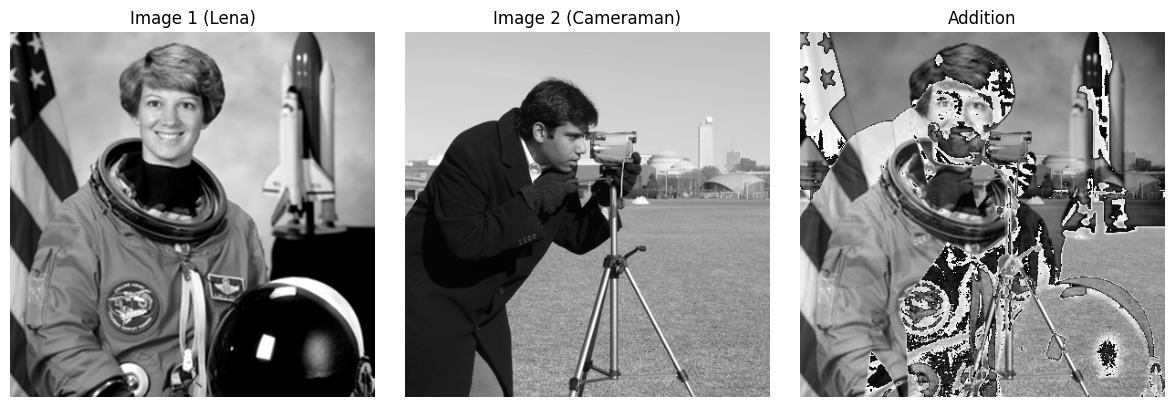

In [4]:
from PIL import Image
img1=Image.open('../images/lena_gray_256.tif')
img2=Image.open('../images/cameraman.tif')

resize=(400,400)
img1=img1.resize(resize,Image.Resampling.LANCZOS)
img2=img2.resize(resize,Image.Resampling.LANCZOS)

im1arr=np.asarray(img1)
im2arr=np.asarray(img2)

addition=im1arr+im2arr
resultImage=Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(im1arr, cmap='gray'); plt.title('Image 1 (Lena)'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(im2arr, cmap='gray'); plt.title('Image 2 (Cameraman)'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(addition, cmap='gray'); plt.title('Addition'); plt.axis('off')
plt.tight_layout(); plt.show()

---
## 3. Sets and Logical Operations

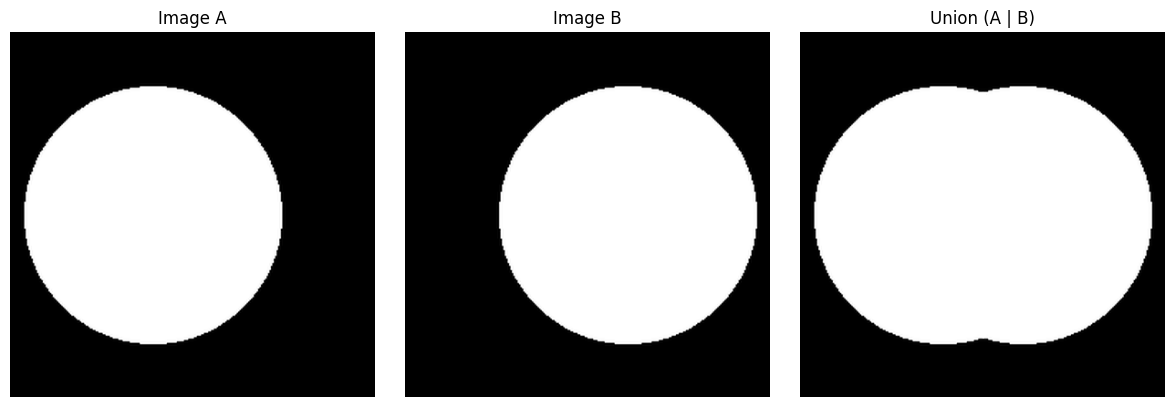

In [5]:
img3=Image.open('../images/A.png')
img4=Image.open('../images/B.png')
resize=(400,400)
img3=img3.resize(resize,Image.Resampling.LANCZOS)
img4=img4.resize(resize,Image.Resampling.LANCZOS)
im3arr=np.asarray(img3)
im4arr=np.asarray(img4)
union=im4arr|im3arr
resultImage2=Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(im3arr, cmap='gray'); plt.title('Image A'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(im4arr, cmap='gray'); plt.title('Image B'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(union, cmap='gray'); plt.title('Union (A | B)'); plt.axis('off')
plt.tight_layout(); plt.show()

---
## Task 1: Change the sampling and quantization parameters and observe the effects

=== Different Sampling Factors ===


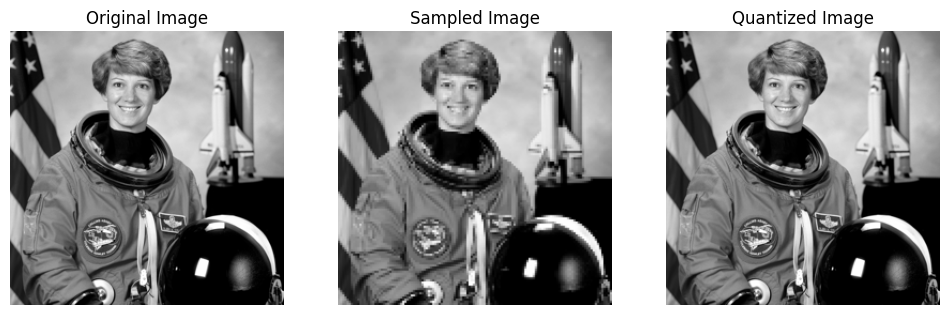

Sampling factor=2: image size reduced from (256, 256) to (128, 128)


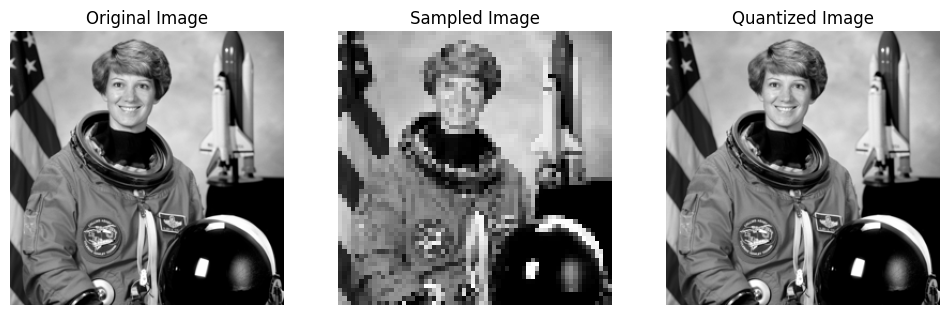

Sampling factor=4: image size reduced from (256, 256) to (64, 64)


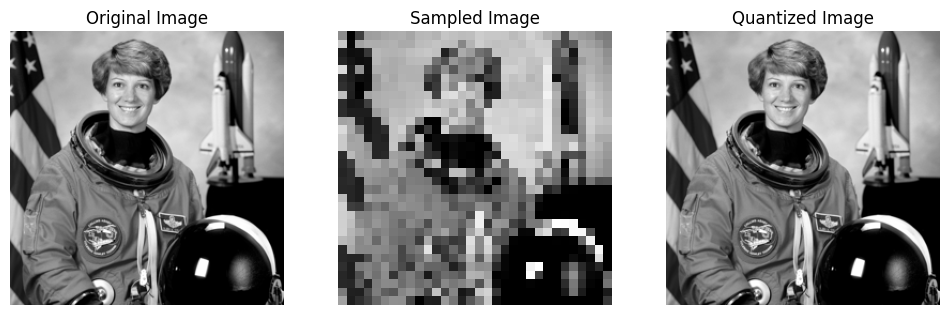

Sampling factor=8: image size reduced from (256, 256) to (32, 32)


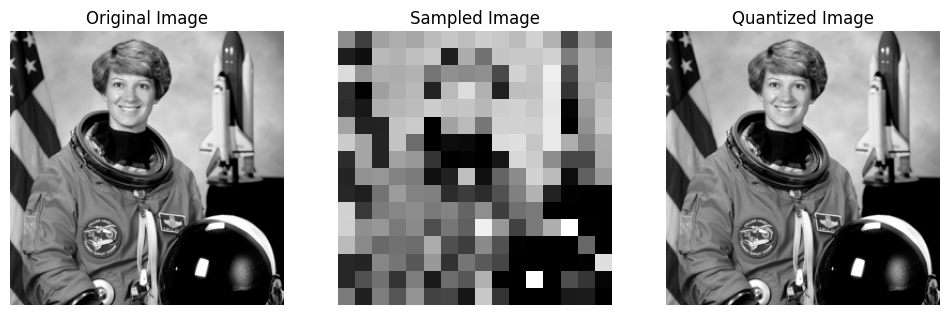

Sampling factor=16: image size reduced from (256, 256) to (16, 16)


In [6]:
# Trying different sampling factors
print("=== Different Sampling Factors ===")
for factor in [2, 4, 8, 16]:
    s = sample_image(original_image, factor)
    q = quantize_image(original_image, 256)  # keep quantization full
    plot_images(original_image, s, q)
    print(f"Sampling factor={factor}: image size reduced from {original_image.shape} to {s.shape}")

=== Different Quantization Levels ===


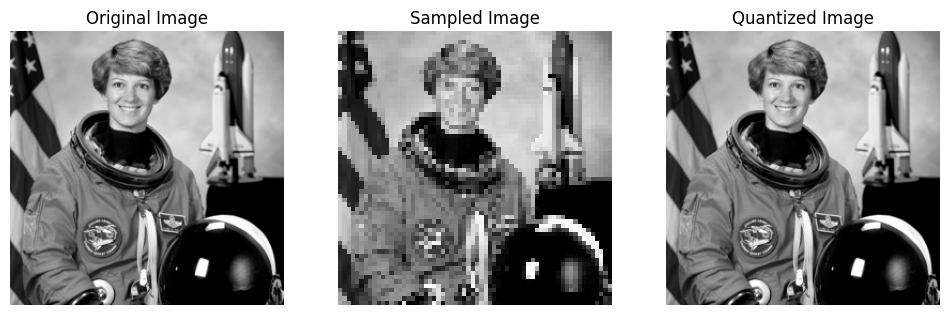

Quantization levels=128: fewer levels = more visible banding


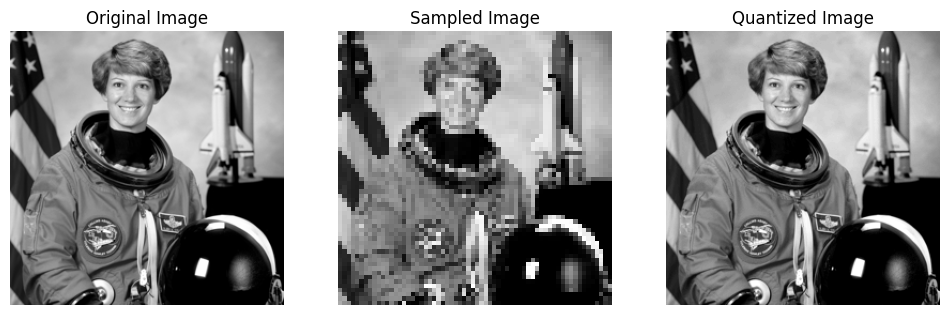

Quantization levels=64: fewer levels = more visible banding


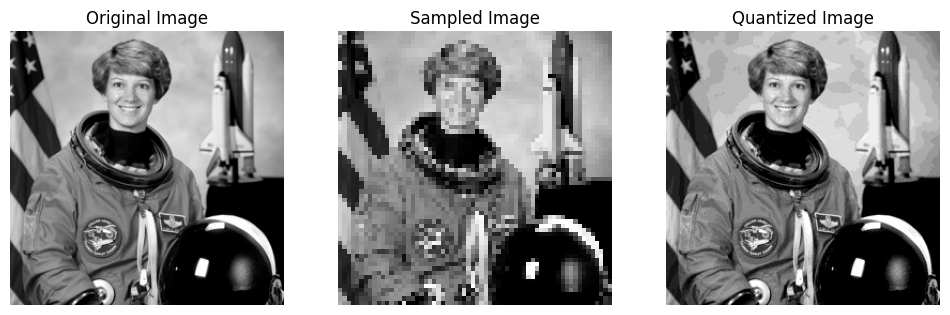

Quantization levels=16: fewer levels = more visible banding


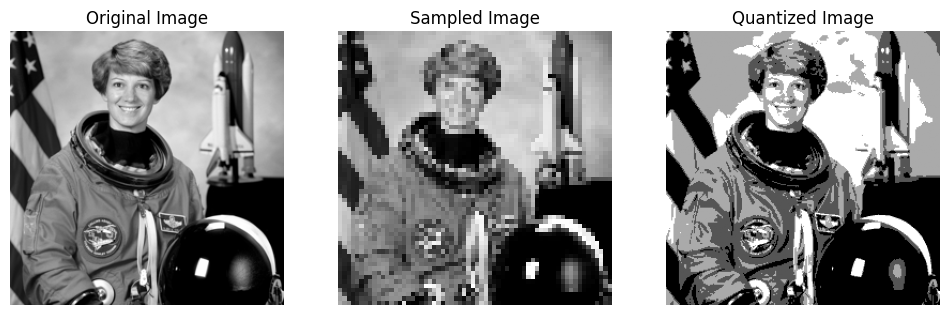

Quantization levels=4: fewer levels = more visible banding


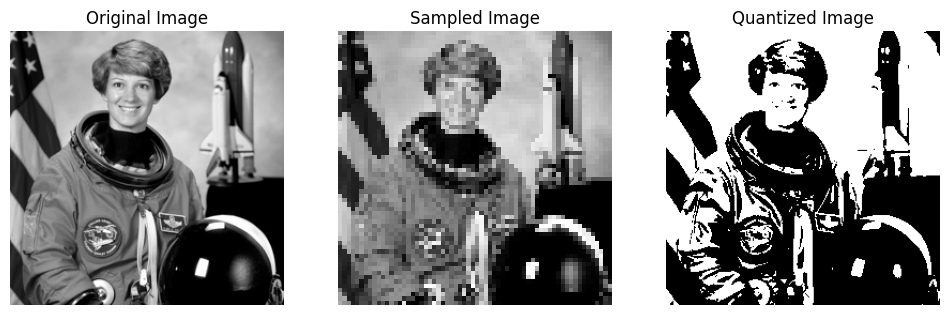

Quantization levels=2: fewer levels = more visible banding


In [7]:
# Trying different quantization levels
print("=== Different Quantization Levels ===")
for levels in [128, 64, 16, 4, 2]:
    s = sample_image(original_image, 4)  # keep sampling fixed
    q = quantize_image(original_image, levels)
    plot_images(original_image, s, q)
    print(f"Quantization levels={levels}: fewer levels = more visible banding")

---
## Task 2: Arithmetic and Logical Operations on Two Images

### 2.1 — Subtract two images and display the result

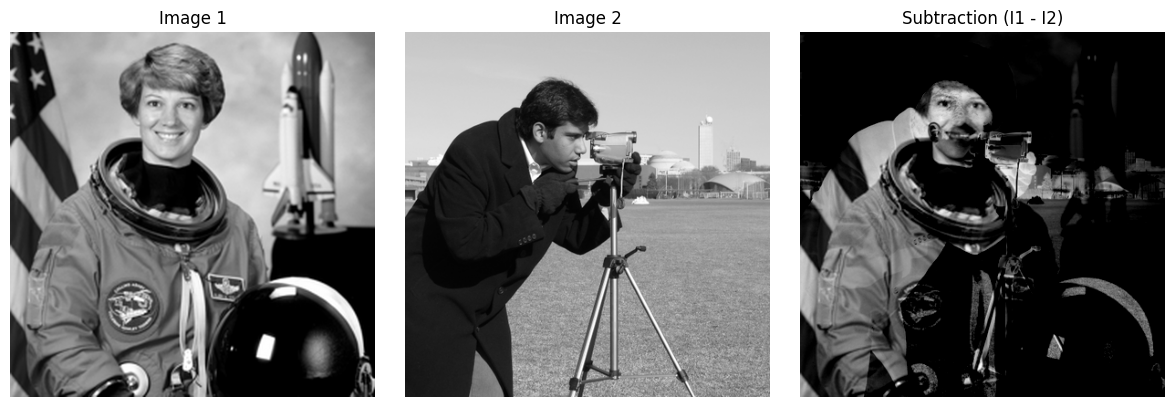

In [8]:
subtraction = im1arr.astype(np.int16) - im2arr.astype(np.int16)
subtraction = np.clip(subtraction, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(im1arr, cmap='gray'); plt.title('Image 1'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(im2arr, cmap='gray'); plt.title('Image 2'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(subtraction, cmap='gray'); plt.title('Subtraction (I1 - I2)'); plt.axis('off')
plt.tight_layout()
plt.show()

### 2.2 — Add one image with a constant value of 175 and display it

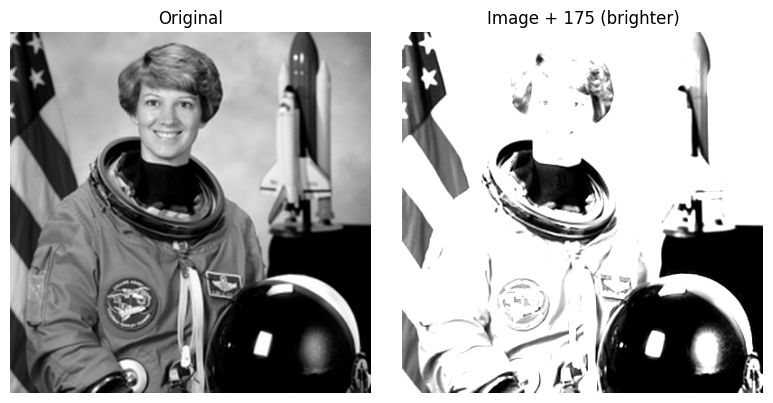

In [9]:
add_constant = im1arr.astype(np.int16) + 175
add_constant = np.clip(add_constant, 0, 255).astype(np.uint8)

plt.figure(figsize=(8, 4))
plt.subplot(1,2,1); plt.imshow(im1arr, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(add_constant, cmap='gray'); plt.title('Image + 175 (brighter)'); plt.axis('off')
plt.tight_layout()
plt.show()

### 2.3 — Set Difference operation on two Gray-Scale images
**Formula:** A - B = A AND (NOT B) — pixels in A but not in B

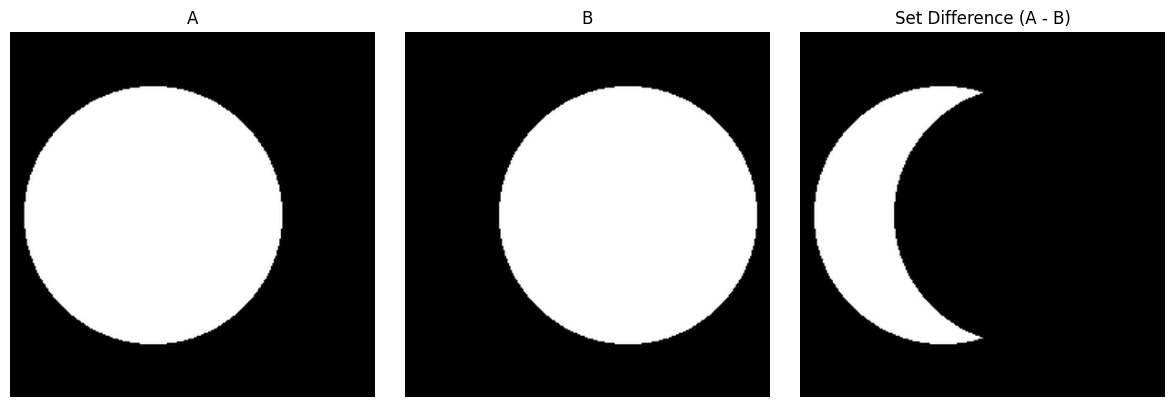

In [10]:
set_difference = im3arr & (~im4arr)

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(im3arr, cmap='gray'); plt.title('A'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(im4arr, cmap='gray'); plt.title('B'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(set_difference, cmap='gray'); plt.title('Set Difference (A - B)'); plt.axis('off')
plt.tight_layout()
plt.show()

### 2.4 — Symmetric Difference operation on two Gray-Scale images
**Formula:** A XOR B — pixels in A or B but not both

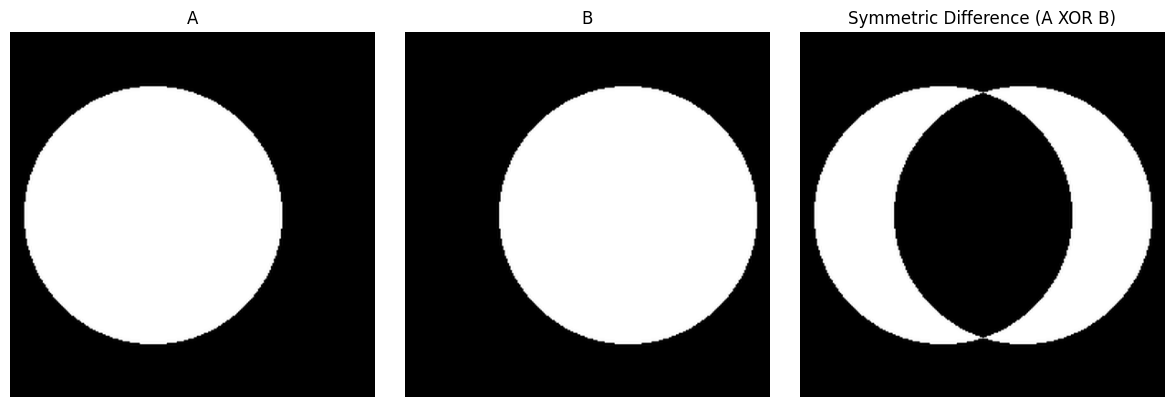

In [11]:
symmetric_difference = im3arr ^ im4arr

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(im3arr, cmap='gray'); plt.title('A'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(im4arr, cmap='gray'); plt.title('B'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(symmetric_difference, cmap='gray'); plt.title('Symmetric Difference (A XOR B)'); plt.axis('off')
plt.tight_layout()
plt.show()

### 2.5 — Intersection operation on two Gray-Scale images
**Formula:** A AND B — pixels present in both A and B

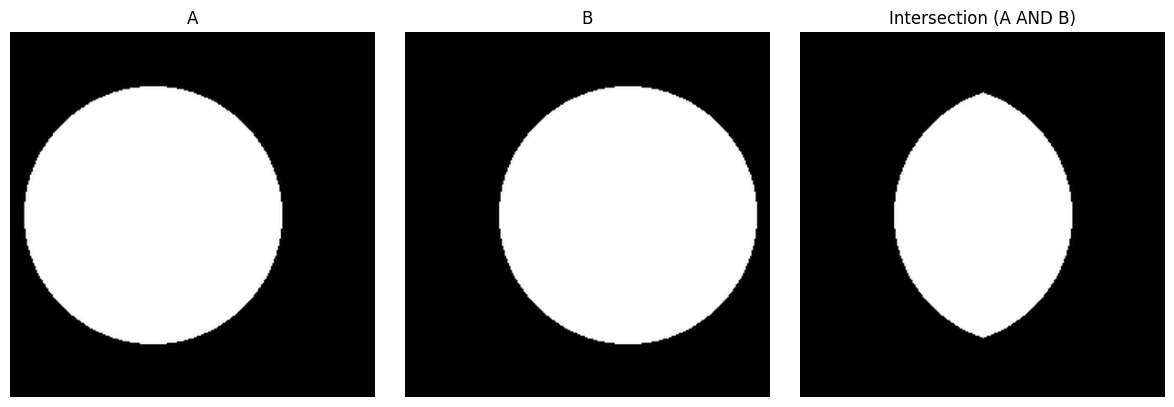

In [12]:
intersection = im3arr & im4arr

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(im3arr, cmap='gray'); plt.title('A'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(im4arr, cmap='gray'); plt.title('B'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(intersection, cmap='gray'); plt.title('Intersection (A AND B)'); plt.axis('off')
plt.tight_layout()
plt.show()